<a href="https://colab.research.google.com/github/jiyuutheosum/Machine-Learning/blob/main/Machine_Learning_PIT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name: [ Jalanie Baraocor ] [ Sherri Nicole Tilan ]**

**BSIT - 4R8 - Machine Learning**

## **1. Importing libraries**

In [4]:
# === Install & downloads (run once in Colab) ===
# !pip install -q pyspellchecker
# !pip install -q scikit-learn
# !pip install -q transformers datasets evaluate
# !pip install shap

import re
import joblib
import io
import shap
import nltk
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import hf_xet

from tqdm import tqdm
from huggingface_hub import HfFolder
from sklearn.model_selection import train_test_split
from sklearn.utils import compute_class_weight
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression, RidgeClassifier, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from spellchecker import SpellChecker
from google.colab import files

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer   # type: ignore
from tensorflow.keras.preprocessing.sequence import pad_sequences   # type: ignore
from tensorflow.keras.models import Sequential  # type: ignore
from tensorflow.keras.layers import Embedding, Dense, Dropout, Conv1D, GlobalMaxPool1D, LSTM     # type: ignore
from tensorflow.keras.callbacks import EarlyStopping     # type: ignore
from transformers import DistilBertTokenizerFast, TFDistilBertForSequenceClassification, BertForSequenceClassification

# Use Python APIs to clear Hugging Face cache (avoid shell magic which can be brittle in some environments)
import os
import shutil
hf_cache_home = os.getenv('HF_HOME', os.path.join(os.path.expanduser('~'), '.cache', 'huggingface'))
if os.path.exists(hf_cache_home):
    try:
        shutil.rmtree(hf_cache_home)
        print(f"Hugging Face cache cleared: {hf_cache_home}")
    except Exception as e:
        print(f"Failed to remove Hugging Face cache {hf_cache_home}: {e}")
else:
    print(f"Hugging Face cache directory not found: {hf_cache_home}")

# NLTK downloads
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

Hugging Face cache directory not found: /root/.cache/huggingface


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# **2. Load Dataset**

In [42]:
print("Upload your dataset (.xlsx or .csv)")
uploaded = files.upload()   # Opens the file picker UI

# Automatically detect the uploaded file name
file_name = next(iter(uploaded))

# Load Excel or CSV
if file_name.endswith(".xlsx"):
    df = pd.read_excel(io.BytesIO(uploaded[file_name]))
elif file_name.endswith(".csv"):
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
else:
    raise ValueError("Unsupported file type. Please upload .xlsx or .csv")

print("\nDataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())

Upload your dataset (.xlsx or .csv)


Saving full-translated-to-eng-dataset2.xlsx to full-translated-to-eng-dataset2 (4).xlsx

Dataset loaded successfully!
Shape: (46546, 3)


,sents,sentiments,topics
0,Full course slides .,2,1
1,"Enthusiastic teaching, close to students.",2,0
2,Attend school with full marks for attendance.,0,1
3,have not yet applied information technology an...,0,0
4,"The teacher teaches well, there are many examp...",2,0


In [43]:
print(df["sents"].head(20))
print(df["sents"].dtype)

0                                 Full course slides . 
1            Enthusiastic teaching, close to students. 
2        Attend school with full marks for attendance. 
3     have not yet applied information technology an...
4     The teacher teaches well, there are many examp...
5     lecturers ensure class time , actively answer ...
6     Your name is too long but I remember it as a g...
7                                     yes no comments. 
8                                          well okay . 
9                                           web test . 
10                 We took about 4 weeks off like that.
11    we represent freshmen, and we be still not abl...
12    we represent freshmen, and we be still not abl...
13    The study time is too long, not guaranteeing e...
14    The subject content is somewhat lacking in foc...
15    need to speak more clearly by presenting on th...
16    The teacher is very dedicated and comes to tea...
17                                   easily pres

# **3. Label Mapping**

In [44]:
# 1. Define your column names directly
TEXT_COL = "sents"
LABEL_COL = "sentiments"

# 2. Keep only the necessary columns
df = df[[TEXT_COL, LABEL_COL]].rename(columns={
    TEXT_COL: "text",
    LABEL_COL: "label"
}).dropna().reset_index(drop=True)

# 3. Ensure label is numeric (0/1)
df["label"] = df["label"].astype(int)

# 4. (Optional) sample if dataset is huge
SAMPLE_N = 10000
if len(df) > SAMPLE_N:
    df = df.sample(SAMPLE_N, random_state=42).reset_index(drop=True)

print(df.head())
print("Label distribution:\n", df["label"].value_counts())


                                                text  label
0  She teaches very enthusiastically, giving stud...      2
1  The system of grading projects according to th...      2
2  Although this learning method acting is quite ...      1
3  Although the teacher is small, he has a very c...      2
4  Classroom necessitate to install more fans and...      0
Label distribution:
 label
0    3510
1    3317
2    3173
Name: count, dtype: int64


# **4. Data Preprocessing**

In [46]:
# === Preprocessing pipeline (cached spellchecker) ===
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
speaker = SpellChecker(distance=1)
spell_cache = {}

def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'http\S+|www.\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # reduce repeated chars
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    tokens = word_tokenize(text)
    cleaned = []
    for t in tokens:
        if t in stop_words:
            continue
        if len(t) > 2:
            if t in spell_cache:
                t = spell_cache[t]
            else:
                corr = speaker.correction(t)
                if corr:
                    spell_cache[t] = corr
                    t = corr
        t = lemmatizer.lemmatize(t)
        cleaned.append(t)
    return " ".join(cleaned)

# Apply
df['clean_text'] = df[text_col].astype(str).map(clean_text)
display(df[['clean_text']].head(8))

,clean_text
0,teach enthusiastically giving student access m...
1,system grading project according level closing...
2,although learning method acting quite effectiv...
3,although teacher small clear voice authority m...
4,classroom necessitate install fan socket stude...
5,necessary arrange classroom accordance number ...
6,classroom need install devotee socket educatee...
7,1 give watch teaching say subject must laborat...


# **5. Train-Test Split**

In [47]:
# === split into train/val/test (70/15/15 stratified) ===
X = df['clean_text'].values
y = df['label'].values
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
val_relative = 0.15 / (1 - 0.15)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=val_relative, random_state=42, stratify=y_train_val)
print("Sizes: train", len(X_train), "val", len(X_val), "test", len(X_test))

Sizes: train 7000 val 1500 test 1500


# **6. Feature Extraction TF-IDF & BoW**

In [48]:
# === feature extraction (TF-IDF & BoW) ===
bow = CountVectorizer(ngram_range=(1,1), max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_val_bow = bow.transform(X_val)
X_test_bow = bow.transform(X_test)

corpus = df['clean_text'].fillna('').tolist()
X_counts = bow.fit_transform(corpus)  # sparse matrix (n_docs x n_features)
print("BoW shape:", X_counts.shape)

# Convert to DataFrame (feature names as columns)
bow_df = pd.DataFrame(X_counts.toarray(), columns=bow.get_feature_names_out())
bow_df.index = df.index  # align indices with original df
bow_df.head()

BoW shape: (10000, 3215)


,00,10,10th,11,13h00,13h30,140,14h00,15,16,...,wzjwz81,wzjwz82,wzjwz97,year,yell,yes,yet,young,your,youthful
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
tfidf = TfidfVectorizer(ngram_range=(1,1), max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

X_tfidf = tfidf.fit_transform(corpus)
print("TF-IDF shape:", X_tfidf.shape)

tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
tfidf_df.index = df.index
tfidf_df.head()

TF-IDF shape: (10000, 3215)


,00,10,10th,11,13h00,13h30,140,14h00,15,16,...,wzjwz81,wzjwz82,wzjwz97,year,yell,yes,yet,young,your,youthful
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# **7. Handling Imbalance**

In [50]:
smote = SMOTE(random_state=42)

# APPLY SMOTE (TF-IDF VERSION)
X_train_tfidf_sm, y_train_sm = smote.fit_resample(X_train_tfidf, y_train)
print("TF-IDF SMOTE applied. \nClass counts:",
      {0: sum(y_train_sm==0), 1: sum(y_train_sm==1)})


# APPLY SMOTE (BoW VERSION)
X_train_bow_sm, y_train_bow_sm = smote.fit_resample(X_train_bow, y_train)
print("BoW SMOTE applied. \nClass counts:",
      {0: sum(y_train_bow_sm==0), 1: sum(y_train_bow_sm==1)})

TF-IDF SMOTE applied. 
Class counts: {0: np.int64(2457), 1: np.int64(2457)}
BoW SMOTE applied. 
Class counts: {0: np.int64(2457), 1: np.int64(2457)}


# **8. Train Classical Models**

In [51]:
# TRAINING CLASSICAL MODEL

# Ensure 'models' dict exists and is properly defined (recreate if not)
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "LinearSVC": LinearSVC(max_iter=10000, class_weight='balanced'),
    "MultinomialNB": MultinomialNB(),  # NB does NOT support class weights
    "RidgeClassifier": RidgeClassifier(class_weight='balanced'),
    "PassiveAggressive": PassiveAggressiveClassifier(max_iter=1000, class_weight='balanced')
}

trained_models = {}
val_predictions = {}


# Train using TF-IDF features
print("\nTraining TF-IDF models (with SMOTE)...")
for name, clf in list(models.items()):
    try:
        estimator = clf
        estimator.fit(X_train_tfidf_sm, y_train_sm)
        trained_models[f"{name}_tfidf"] = estimator
        val_predictions[f"{name}_tfidf"] = estimator.predict(X_val_tfidf)
        print(f"  ✅ Trained {name}_tfidf")
    except Exception as e:
        print(f"  ❌ Error training {name}_tfidf:")
        traceback.print_exc()

# Train using BoW features
print("\nTraining BoW models (with SMOTE)...")
for name, clf in list(models.items()):
    try:
        estimator = clf
        estimator.fit(X_train_bow_sm, y_train_bow_sm)
        trained_models[f"{name}_bow"] = estimator
        val_predictions[f"{name}_bow"] = estimator.predict(X_val_bow)
        print(f"  ✅ Trained {name}_bow")
    except Exception as e:
        print(f"  ❌ Error training {name}_bow:")
        traceback.print_exc()

print("\nTraining finished. Trained models:", list(trained_models.keys()))


Training TF-IDF models (with SMOTE)...
  ✅ Trained LogisticRegression_tfidf
  ✅ Trained LinearSVC_tfidf
  ✅ Trained MultinomialNB_tfidf
  ✅ Trained RidgeClassifier_tfidf
  ✅ Trained PassiveAggressive_tfidf

Training BoW models (with SMOTE)...
  ✅ Trained LogisticRegression_bow
  ✅ Trained LinearSVC_bow
  ✅ Trained MultinomialNB_bow
  ✅ Trained RidgeClassifier_bow
  ✅ Trained PassiveAggressive_bow

Training finished. Trained models: ['LogisticRegression_tfidf', 'LinearSVC_tfidf', 'MultinomialNB_tfidf', 'RidgeClassifier_tfidf', 'PassiveAggressive_tfidf', 'LogisticRegression_bow', 'LinearSVC_bow', 'MultinomialNB_bow', 'RidgeClassifier_bow', 'PassiveAggressive_bow']


# **9. Evaluating Classic ML Models**


=== LogisticRegression_tfidf ===
Accuracy:    0.9367
Precision:   0.9375
Recall:      0.9366
F1 (binary): 0.9370
F1 (macro):  0.9370

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92       527
           1       0.99      0.96      0.97       497
           2       0.92      0.92      0.92       476

    accuracy                           0.94      1500
   macro avg       0.94      0.94      0.94      1500
weighted avg       0.94      0.94      0.94      1500



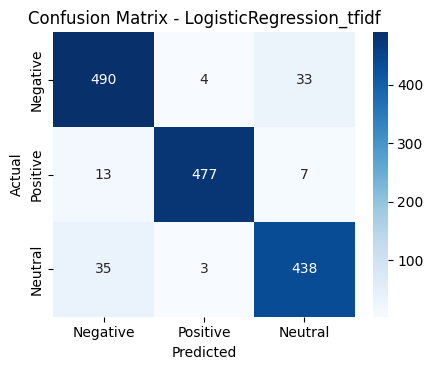


=== LinearSVC_tfidf ===
Accuracy:    0.9353
Precision:   0.9359
Recall:      0.9353
F1 (binary): 0.9356
F1 (macro):  0.9356

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92       527
           1       0.98      0.96      0.97       497
           2       0.91      0.92      0.92       476

    accuracy                           0.94      1500
   macro avg       0.94      0.94      0.94      1500
weighted avg       0.94      0.94      0.94      1500



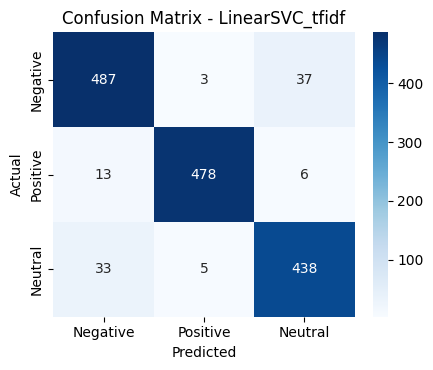


=== MultinomialNB_tfidf ===
Accuracy:    0.9160
Precision:   0.9164
Recall:      0.9174
F1 (binary): 0.9161
F1 (macro):  0.9161

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.86      0.89       527
           1       0.95      0.96      0.96       497
           2       0.87      0.93      0.90       476

    accuracy                           0.92      1500
   macro avg       0.92      0.92      0.92      1500
weighted avg       0.92      0.92      0.92      1500



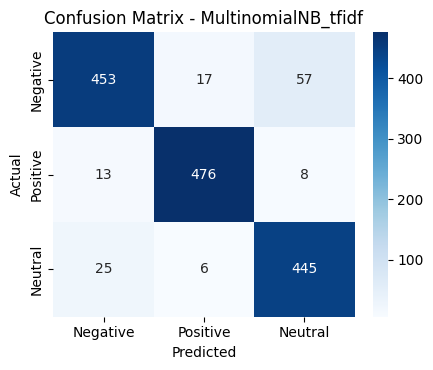


=== RidgeClassifier_tfidf ===
Accuracy:    0.9300
Precision:   0.9307
Recall:      0.9300
F1 (binary): 0.9302
F1 (macro):  0.9302

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92       527
           1       0.98      0.96      0.97       497
           2       0.90      0.91      0.91       476

    accuracy                           0.93      1500
   macro avg       0.93      0.93      0.93      1500
weighted avg       0.93      0.93      0.93      1500



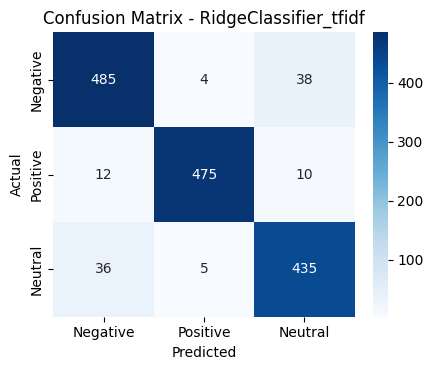


=== PassiveAggressive_tfidf ===
Accuracy:    0.9267
Precision:   0.9267
Recall:      0.9272
F1 (binary): 0.9269
F1 (macro):  0.9269

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.91       527
           1       0.97      0.96      0.96       497
           2       0.90      0.92      0.91       476

    accuracy                           0.93      1500
   macro avg       0.93      0.93      0.93      1500
weighted avg       0.93      0.93      0.93      1500



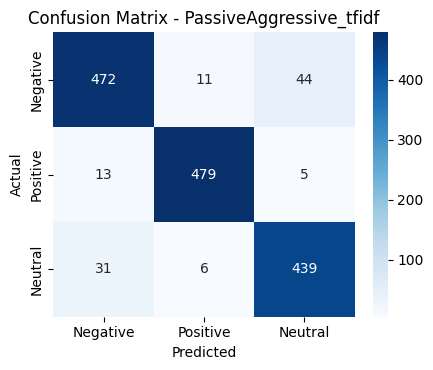


=== LogisticRegression_bow ===
Accuracy:    0.9307
Precision:   0.9316
Recall:      0.9307
F1 (binary): 0.9310
F1 (macro):  0.9310

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.91       527
           1       0.99      0.96      0.97       497
           2       0.90      0.92      0.91       476

    accuracy                           0.93      1500
   macro avg       0.93      0.93      0.93      1500
weighted avg       0.93      0.93      0.93      1500



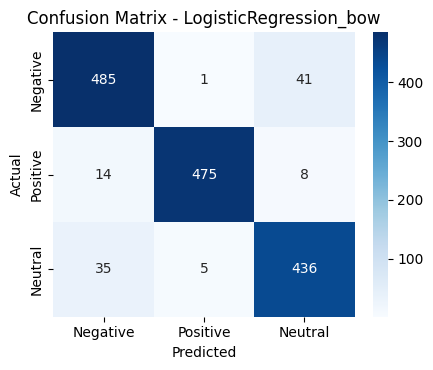


=== LinearSVC_bow ===
Accuracy:    0.9267
Precision:   0.9269
Recall:      0.9270
F1 (binary): 0.9269
F1 (macro):  0.9269

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91       527
           1       0.97      0.96      0.96       497
           2       0.89      0.92      0.91       476

    accuracy                           0.93      1500
   macro avg       0.93      0.93      0.93      1500
weighted avg       0.93      0.93      0.93      1500



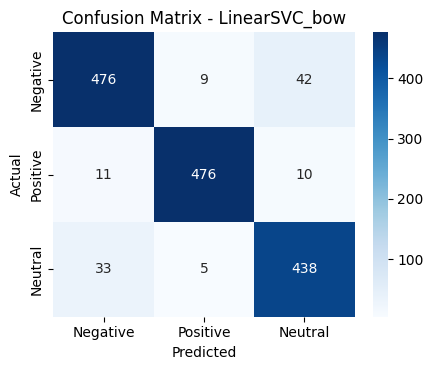


=== MultinomialNB_bow ===
Accuracy:    0.9013
Precision:   0.9024
Recall:      0.9035
F1 (binary): 0.9012
F1 (macro):  0.9012

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.82      0.87       527
           1       0.94      0.96      0.95       497
           2       0.85      0.93      0.89       476

    accuracy                           0.90      1500
   macro avg       0.90      0.90      0.90      1500
weighted avg       0.90      0.90      0.90      1500



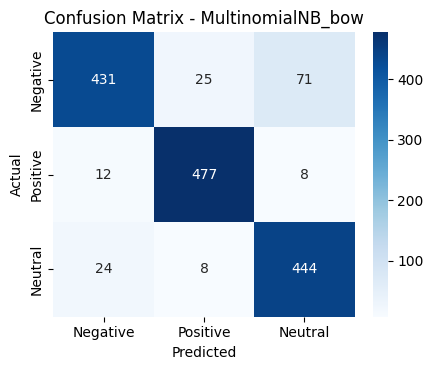


=== RidgeClassifier_bow ===
Accuracy:    0.9253
Precision:   0.9262
Recall:      0.9257
F1 (binary): 0.9257
F1 (macro):  0.9257

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.91       527
           1       0.99      0.95      0.97       497
           2       0.88      0.92      0.90       476

    accuracy                           0.93      1500
   macro avg       0.93      0.93      0.93      1500
weighted avg       0.93      0.93      0.93      1500



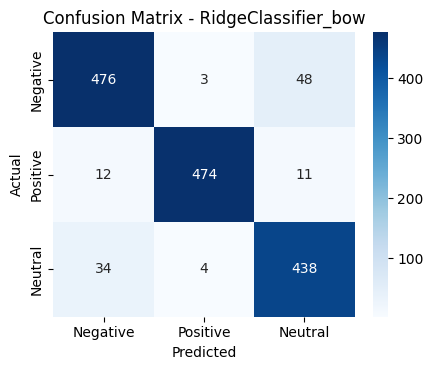


=== PassiveAggressive_bow ===
Accuracy:    0.9213
Precision:   0.9212
Recall:      0.9223
F1 (binary): 0.9213
F1 (macro):  0.9213

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.88      0.90       527
           1       0.95      0.96      0.96       497
           2       0.89      0.93      0.91       476

    accuracy                           0.92      1500
   macro avg       0.92      0.92      0.92      1500
weighted avg       0.92      0.92      0.92      1500



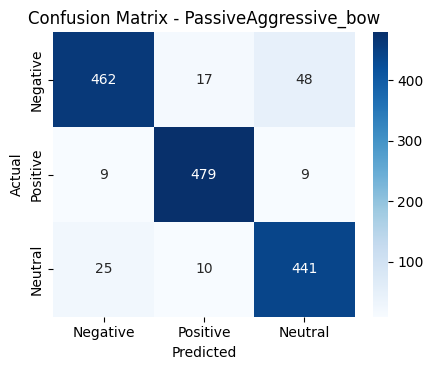

In [55]:
# === EVALUATION OF ALL MODELS (with Confusion Matrix Plot) ===
eval_results = []

for name, preds in val_predictions.items():
    acc = accuracy_score(y_val, preds)
    prec = precision_score(y_val, preds, average='macro', zero_division=0)
    rec = recall_score(y_val, preds, average='macro', zero_division=0)
    f1 = f1_score(y_val, preds, average='macro', zero_division=0)
    f1_macro = f1_score(y_val, preds, average='macro', zero_division=0)
    cm = confusion_matrix(y_val, preds)

    print(f"\n=== {name} ===")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Precision:   {prec:.4f}")
    print(f"Recall:      {rec:.4f}")
    print(f"F1 (binary): {f1:.4f}")
    print(f"F1 (macro):  {f1_macro:.4f}")
    print("\nClassification Report:\n", classification_report(y_val, preds, zero_division=0))

    # ---- Improved Confusion Matrix ----
    # Tick labels (0 = Negative, 1 = Positive)
    plt.figure(figsize=(4.5, 3.8))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=['Negative', 'Positive', 'Neutral'],
                yticklabels=['Negative', 'Positive', 'Neutral'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    # -----------------------------------

    eval_results.append({
        'model': name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_binary': f1,
        'f1_macro': f1_macro
    })


# **10. Picking the best Model**

Best TF-IDF model on validation: LogisticRegression_tfidf
Selected final model for testing: LogisticRegression_tfidf

Final Test Metrics:
Accuracy : 0.9353
Precision: 0.9354
Recall   : 0.9357
F1 Score : 0.9355


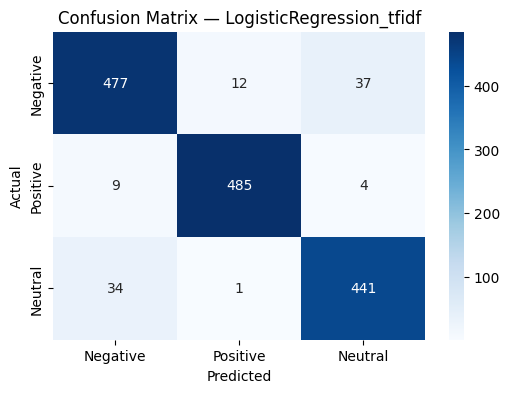

In [58]:
# ==========================================
# PICK BEST TF-IDF MODEL & EVALUATE ON TEST
# ==========================================

# Filter TF-IDF models and pick best by F1 (using f1_macro for multiclass)
best = max(
    (r for r in eval_results if "_tfidf" in r["model"]),
    key=lambda x: x["f1_macro"] # Use f1_macro for multiclass evaluation
)
print("Best TF-IDF model on validation:", best["model"])

# Retrieve the trained model directly from the dictionary
final_model = trained_models[best["model"]]
print(f"Selected final model for testing: {best['model']}")

# Merge train + validation data
from scipy.sparse import vstack
X_train_val_tfidf = vstack([X_train_tfidf, X_val_tfidf])
y_train_val = np.concatenate([y_train, y_val])

# Train final model on combined data (re-train for final evaluation on test set)
final_model.fit(X_train_val_tfidf, y_train_val)

# Predict on test
test_preds = final_model.predict(X_test_tfidf)

# ===================
# METRICS
# ===================
print("\nFinal Test Metrics:")
print(f"Accuracy : {accuracy_score(y_test, test_preds):.4f}")
# Ensure average is 'macro' for multiclass metrics
print(f"Precision: {precision_score(y_test, test_preds, average='macro', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, test_preds, average='macro', zero_division=0):.4f}")
print(f"F1 Score : {f1_score(y_test, test_preds, average='macro', zero_division=0):.4f}")

# ===================
# CONFUSION MATRIX HEATMAP
# ===================
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Negative', 'Positive', 'Neutral'], # Corrected for 3 classes
            yticklabels=['Negative', 'Positive', 'Neutral']) # Corrected for 3 classes
plt.title(f"Confusion Matrix — {best['model']}") # Use best['model'] for title
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **11. XAI SHAP on Classical Model**

Initializing SHAP explainer...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


SHAP values computed.


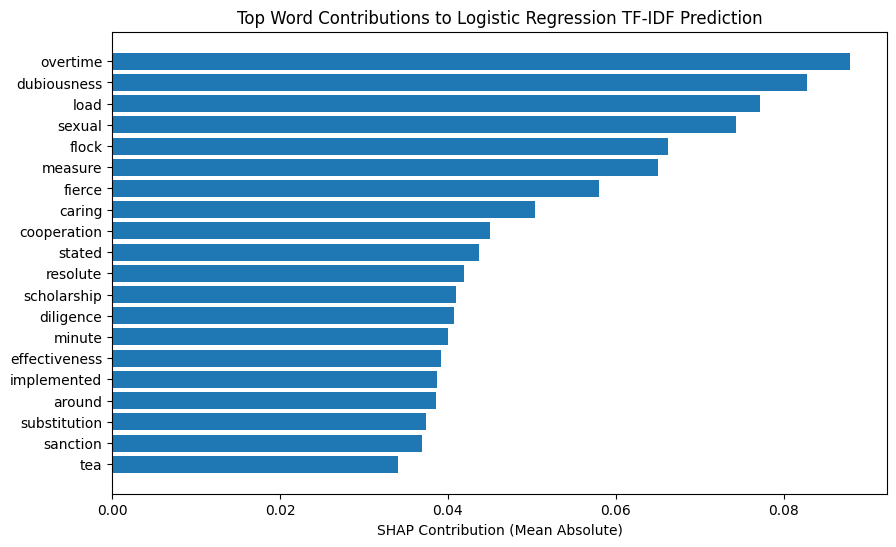

In [74]:
# === SHAP for Logistic Regression + TF-IDF ===
print("Initializing SHAP explainer...")

# SHAP needs dense data for LinearExplainer
X_train_sample = X_train_tfidf[:500].toarray()  # reduce to 500 for speed
X_test_dense = X_test_tfidf.toarray()

# Create SHAP explainer
explainer = shap.LinearExplainer(final_model, X_train_sample, feature_perturbation="interventional")

# Compute SHAP values for test data
# For multiclass, shap_values will be a list of arrays (one for each class) OR a single 3D array
shap_values = explainer.shap_values(X_test_dense)

print("SHAP values computed.")

# === GLOBAL IMPORTANT WORDS ===

feature_names = tfidf.get_feature_names_out()

# Correctly compute global_shap_values for multiclass output
if isinstance(shap_values, list):
    # This branch handles when shap_values is a list of (n_samples, n_features) arrays (one per class)
    # 1. Take absolute value for each class's SHAP array
    abs_shap_values_per_class = [np.abs(s_vals) for s_vals in shap_values]
    # 2. Stack them into a 3D array: (num_classes, n_samples, n_features)
    stacked_abs_shap_values = np.stack(abs_shap_values_per_class)
    # 3. Compute the mean across samples (axis=1) and classes (axis=0) to get one value per feature
    global_shap_values = np.mean(stacked_abs_shap_values, axis=(0, 1))
else:
    # This branch handles when shap_values is a single ndarray
    # Assuming its shape is (n_samples, n_features, n_classes)
    # We need to average over samples (axis=0) and classes (axis=2) to get one value per feature
    global_shap_values = np.mean(np.abs(shap_values), axis=(0, 2))

# Get top N words
N = 20 # Number of top words to display
sorted_idx = np.argsort(global_shap_values)[::-1][:N]
top_tokens = [feature_names[i] for i in sorted_idx]
top_scores = global_shap_values[sorted_idx]

plt.figure(figsize=(10,6))
ypos = np.arange(len(top_tokens))
plt.barh(ypos, top_scores)
plt.yticks(ypos, top_tokens)
plt.xlabel("SHAP Contribution (Mean Absolute)")
plt.title("Top Word Contributions to Logistic Regression TF-IDF Prediction")
plt.gca().invert_yaxis()
plt.show()

# **12. Deep Learning**

In [60]:
# PREP TEXT FOR DEEP LEARNING

MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<UNK>")
# use the already-defined train/val arrays (clean text) named X_train and X_val
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post')

# **13. CNN Model**

In [61]:
#Training CNN

cnn_model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    Conv1D(128, 5, activation="relu"),
    GlobalMaxPool1D(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_cnn = cnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - accuracy: 0.3619 - loss: -2.0343 - val_accuracy: 0.5000 - val_loss: -90.6596
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - accuracy: 0.4566 - loss: -507.5363 - val_accuracy: 0.4960 - val_loss: -4426.6885
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - accuracy: 0.4709 - loss: -8321.6758 - val_accuracy: 0.4447 - val_loss: -32423.3574
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 115ms/step - accuracy: 0.4479 - loss: -47610.5781 - val_accuracy: 0.4733 - val_loss: -121294.3672
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 25s 156ms/step - accuracy: 0.4725 - loss: -155043.0469 - val_accuracy: 0.4733 - val_loss: -323864.7500
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - accuracy: 0.4613 - loss: -404778.9062 - val_accuracy: 0.4820 - val_loss: -697268.5625
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 21s 115ms/step - accuracy: 0.4624 - loss: -826653.1250 - val_accuracy: 0.4733 - val_loss: -1318326.6250
Epoch 8/10
110/1

# **14. Evaluate CNN Model**

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

📌 CNN Classification Report:
              precision    recall  f1-score   support

    Negative       0.35      1.00      0.52       526
    Positive       0.00      0.00      0.00       498
     Neutral       0.00      0.00      0.00       476

    accuracy                           0.35      1500
   macro avg       0.12      0.33      0.17      1500
weighted avg       0.12      0.35      0.18      1500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


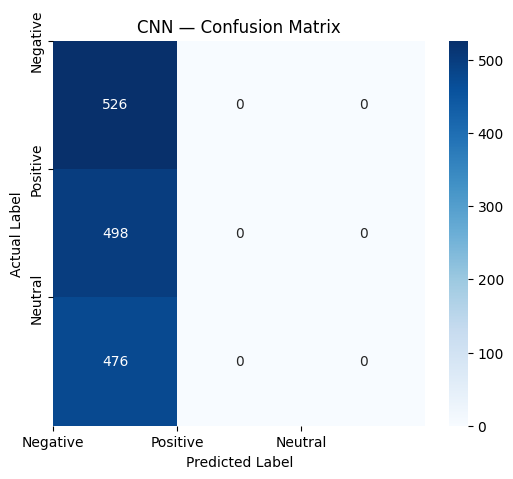

In [67]:
# Prepare test set for CNN
X_test_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=MAX_LEN,
    padding='post'
)

# Predict probabilities (shape: [n_samples, 3])
y_pred_probs = cnn_model.predict(X_test_pad)

# Get class with highest probability
y_pred = np.argmax(y_pred_probs, axis=1)

# CNN Classification Report
print("\n📌 CNN Classification Report:")
target_names = ['Negative', 'Positive', 'Neutral']
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("CNN — Confusion Matrix")
plt.xticks(np.arange(3), target_names)
plt.yticks(np.arange(3), target_names)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# **15. LSTM**

In [68]:
# Training LSTM
lstm_model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    LSTM(128, return_sequences=False),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 41s 290ms/step - accuracy: 0.3223 - loss: 0.2624 - val_accuracy: 0.3313 - val_loss: 0.1484
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 31s 279ms/step - accuracy: 0.3291 - loss: 0.2409 - val_accuracy: 0.3313 - val_loss: 0.1580
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 30s 277ms/step - accuracy: 0.3356 - loss: 0.1410 - val_accuracy: 0.3313 - val_loss: 0.1495
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 31s 284ms/step - accuracy: 0.3264 - loss: 0.1731 - val_accuracy: 0.3313 - val_loss: 0.1546
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 30s 277ms/step - accuracy: 0.3387 - loss: 0.1491 - val_accuracy: 0.3313 - val_loss: 0.1487
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 30s 277ms/step - accuracy: 0.3276 - loss: 0.1464 - val_accuracy: 0.3313 - val_loss: 0.1507
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 30s 277ms/step - accuracy: 0.3317 - loss: 0.1348 - val_accuracy: 0.3313 - val_loss: 0.1487
Epoch 8/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 33s 298ms/step - accuracy: 0.3234 - loss: 0

# **16. Evaluating LSTM**

47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step

📌 CNN Classification Report:
              precision    recall  f1-score   support

    Negative       0.35      1.00      0.52       526
    Positive       0.00      0.00      0.00       498
     Neutral       0.00      0.00      0.00       476

    accuracy                           0.35      1500
   macro avg       0.12      0.33      0.17      1500
weighted avg       0.12      0.35      0.18      1500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


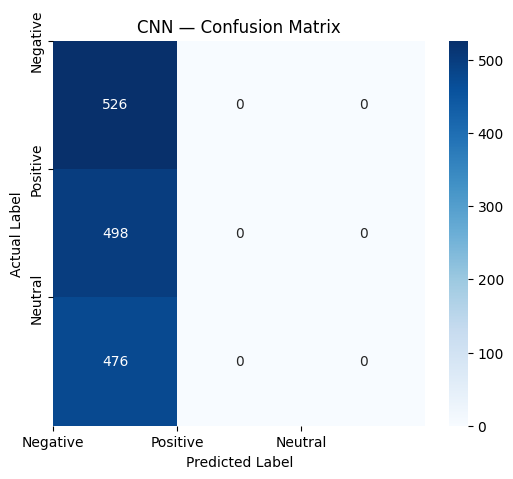

In [69]:
# Prepare test set for LSTM (if not already done)
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post')

# Predict probabilities for test set
y_pred_bin_probs = lstm_model.predict(X_test_pad)
# Convert probabilities to binary predictions (threshold 0.5)
y_pred_bin = (y_pred_bin_probs > 0.5).astype(int).flatten()

# CNN Classification Report
print("\n📌 CNN Classification Report:")
target_names = ['Negative', 'Positive', 'Neutral']
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("CNN — Confusion Matrix")
plt.xticks(np.arange(3), target_names)
plt.yticks(np.arange(3), target_names)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# **17. DistilBERT Model**

In [70]:
# Training DistilBERT (huggingface + tensorflow)
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
train_enc = tokenizer(list(X_train), truncation=True, padding=True, max_length=128)
val_enc = tokenizer(list(X_val), truncation=True, padding=True, max_length=128)

# Explicitly convert labels to tf.int32 to ensure compatibility with SparseCategoricalCrossentropy
train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_enc), tf.convert_to_tensor(y_train, dtype=tf.int32))).shuffle(1000).batch(16)
val_dataset = tf.data.Dataset.from_tensor_slices((dict(val_enc), tf.convert_to_tensor(y_val, dtype=tf.int32))).batch(16)

model = TFDistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2, use_safetensors=False)
optimizer = tf.optimizers.Adam(learning_rate=3e-5)

# Explicitly define the loss function, typically SparseCategoricalCrossentropy for 2-class logits with integer labels
def compute_custom_loss(labels, logits):
    return loss_fn(labels, logits)

model.compile(optimizer=optimizer, loss=compute_custom_loss, metrics=['accuracy'])
model.fit(train_dataset, validation_data=val_dataset, epochs=3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/363M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['activation_13', 'vocab_layer_norm', 'vocab_projector', 'vocab_transform']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-

Epoch 1/3


NameError: in user code:

    File "/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py", line 1398, in train_function  *
        return step_function(self, iterator)
    File "/tmp/ipython-input-502610142.py", line 15, in compute_custom_loss  *
        return loss_fn(labels, logits)

    NameError: name 'loss_fn' is not defined


# **18. Evaluating DistilBERT Model**

In [ ]:
# ----- GET PREDICTIONS -----
pred_output = model.predict(val_dataset)

# Convert logits → probabilities → class labels (0 = Negative, 1 = Positive)
y_pred = np.argmax(pred_output.logits, axis=1)

# ----- GET TRUE LABELS -----
y_true = np.concatenate([y.numpy() for x, y in val_dataset], axis=0)

# ----- CLASSIFICATION REPORT (ALIGNED TO CNN/LSTM) -----
print("\n📊 DISTILBERT CLASSIFICATION REPORT (ALIGNED)\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Negative", "Positive"],
    digits=4
))

# ----- CONFUSION MATRIX -----
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

print("\n📌 CONFUSION MATRIX (Numeric):\n")
print(cm)

classes = ["Negative", "Positive"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)


plt.title("DistilBERT Confusion Matrix")
plt.grid(False)
plt.show()